In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Library berhasil di-import!")

Library berhasil di-import!


In [ ]:
# Tentukan lokasi file
file_path = '/content/drive/MyDrive/Colab Notebooks/mental_health_productivity.csv'

# Baca file CSV
df = pd.read_csv(file_path)

# Tampilkan 5 data teratas untuk memastikan data masuk
df.head()

,Employee_ID,Age,Gender,Country,Industry,Work_Mode,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours,Mental_Health_Support_Access,Burnout_Risk
0,EMP_0001,50,Male,USA,Manufacturing,Remote,40,9,7.377341,89,6.564715,Yes,High
1,EMP_0002,36,Male,UK,Finance,Remote,35,1,6.186889,61,0.184572,Yes,Low
2,EMP_0003,29,Male,Brazil,Finance,Remote,52,4,7.474883,47,8.318881,No,Low
3,EMP_0004,42,Female,UK,Manufacturing,Remote,56,10,7.169386,49,1.746996,No,High
4,EMP_0005,40,Male,Germany,Tech,On-site,35,2,9.518479,53,5.154975,Yes,Low


In [ ]:
# 1. Hapus kolom Employee_ID karena tidak berpengaruh pada prediksi
df_model = df.drop(columns=['Employee_ID'])

# 2. Inisialisasi LabelEncoder
le = LabelEncoder()

# 3. List kolom yang berisi teks (kategorikal)
categorical_cols = ['Gender', 'Country', 'Industry', 'Work_Mode', 'Mental_Health_Support_Access']

# 4. Ubah teks menjadi angka
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Preprocessing selesai. Data sekarang berbentuk angka.")
df_model.head()

Preprocessing selesai. Data sekarang berbentuk angka.


,Age,Gender,Country,Industry,Work_Mode,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours,Mental_Health_Support_Access,Burnout_Risk
0,50,1,9,3,2,40,9,7.377341,89,6.564715,1,High
1,36,1,8,1,2,35,1,6.186889,61,0.184572,1,Low
2,29,1,1,1,2,52,4,7.474883,47,8.318881,0,Low
3,42,0,8,3,2,56,10,7.169386,49,1.746996,0,High
4,40,1,4,5,1,35,2,9.518479,53,5.154975,1,Low


In [ ]:
# X adalah data input (fitur), y adalah target yang ingin ditebak
X = df_model.drop(columns=['Burnout_Risk'])
y = df_model['Burnout_Risk']

# Bagi menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data latih: {X_train.shape[0]} baris")
print(f"Data uji : {X_test.shape[0]} baris")

Data latih: 1200 baris
Data uji : 300 baris


In [ ]:
# Membuat model dengan 100 pohon keputusan
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Proses pelatihan (training)
rf_model.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih!")

Model Random Forest berhasil dilatih!


In [ ]:
# Lakukan prediksi pada data uji
y_pred = rf_model.predict(X_test)

# Tampilkan Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%")

# Tampilkan Laporan Klasifikasi Lengkap
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Akurasi Model: 71.00%

Laporan Klasifikasi:
              precision    recall  f1-score   support

        High       0.97      0.74      0.84       121
         Low       0.68      0.81      0.74       122
      Medium       0.39      0.42      0.41        57

    accuracy                           0.71       300
   macro avg       0.68      0.66      0.66       300
weighted avg       0.74      0.71      0.72       300



/tmp/ipykernel_968/1433761363.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="magma")


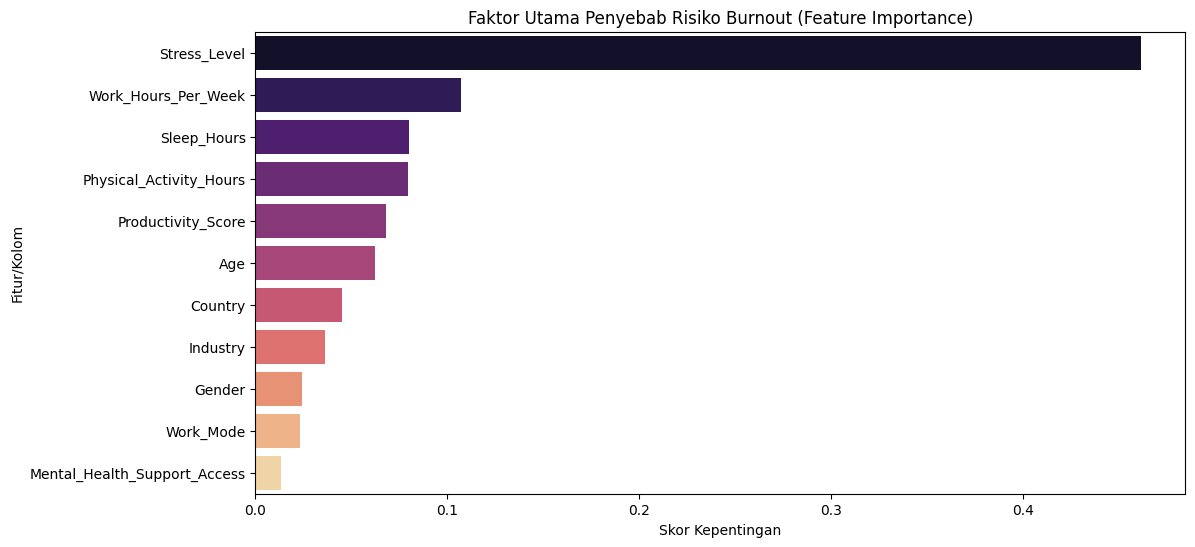

In [ ]:
# Ambil tingkat kepentingan fitur
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Visualisasi
plt.figure(figsize=(12, 6))
plt.title("Faktor Utama Penyebab Risiko Burnout (Feature Importance)")
sns.barplot(x=importances[indices], y=X.columns[indices], palette="magma")
plt.xlabel("Skor Kepentingan")
plt.ylabel("Fitur/Kolom")
plt.show()

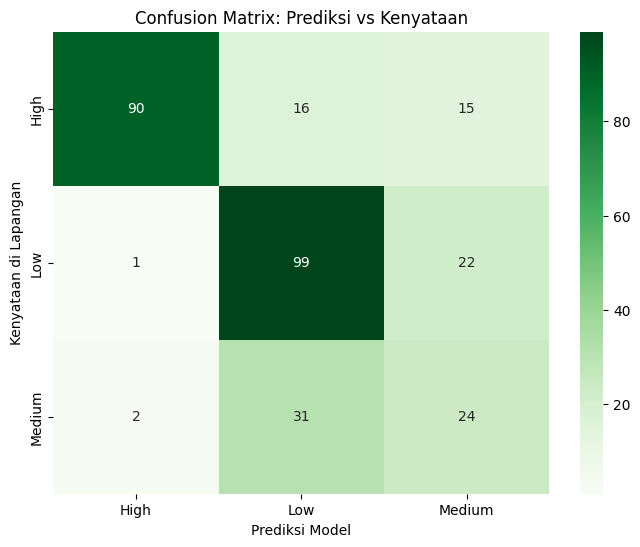

In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.title('Confusion Matrix: Prediksi vs Kenyataan')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan di Lapangan')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

print("Library SMOTE siap digunakan!")

Library SMOTE siap digunakan!


In [ ]:
# 1. Scaling Data (Sangat penting sebelum SMOTE agar jarak antar data akurat)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Menggunakan X yang sudah berbentuk angka dari cell sebelumnya

# 2. Bagi data kembali ke Train & Test (menggunakan data yang sudah di-scale)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Terapkan SMOTE hanya pada data TRAIN (agar tidak ada kebocoran data)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Cek jumlah data sekarang
print("Jumlah data sebelum SMOTE:")
print(y_train.value_counts())
print("\nJumlah data setelah SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Jumlah data sebelum SMOTE:
Burnout_Risk
Low       489
High      473
Medium    238
Name: count, dtype: int64

Jumlah data setelah SMOTE:
Burnout_Risk
Low       489
High      489
Medium    489
Name: count, dtype: int64


In [ ]:
# Membuat model baru
rf_model_balanced = RandomForestClassifier(n_estimators=200, random_state=42)

# Latih dengan data hasil SMOTE
rf_model_balanced.fit(X_train_balanced, y_train_balanced)

print("Model baru berhasil dilatih dengan data seimbang!")

Model baru berhasil dilatih dengan data seimbang!


In [ ]:
# Prediksi menggunakan data uji
y_pred_new = rf_model_balanced.predict(X_test)

# Tampilkan Hasil
print(f"Akurasi Model Terbaru: {accuracy_score(y_test, y_pred_new) * 100:.2f}%")
print("\nLaporan Klasifikasi Terbaru:")
print(classification_report(y_test, y_pred_new))

Akurasi Model Terbaru: 72.00%

Laporan Klasifikasi Terbaru:
              precision    recall  f1-score   support

        High       0.98      0.73      0.83       121
         Low       0.78      0.70      0.74       122
      Medium       0.43      0.75      0.54        57

    accuracy                           0.72       300
   macro avg       0.73      0.73      0.70       300
weighted avg       0.79      0.72      0.74       300



/tmp/ipykernel_968/2617578803.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


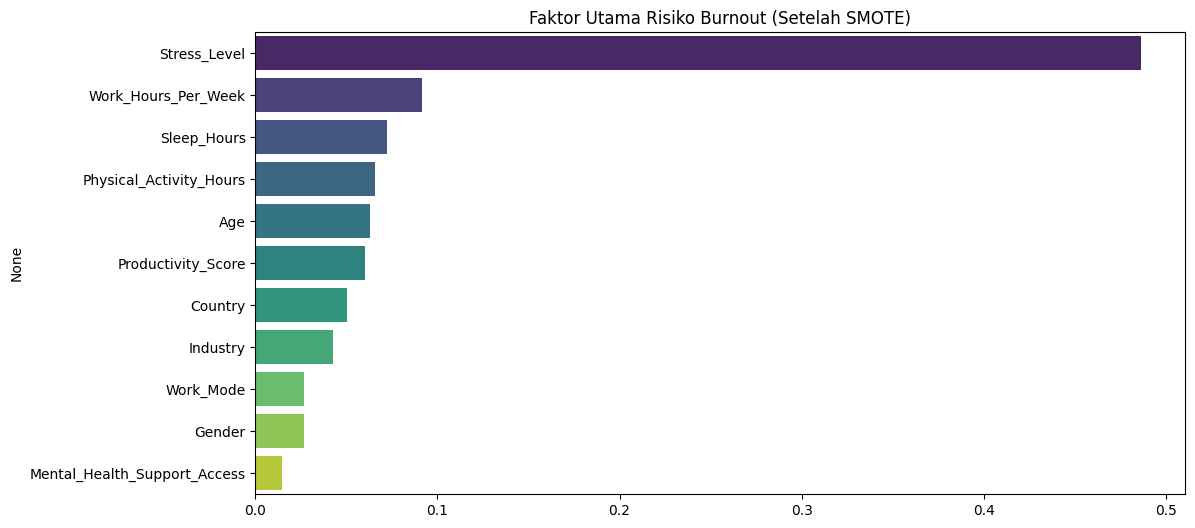

In [ ]:
importances = rf_model_balanced.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Faktor Utama Risiko Burnout (Setelah SMOTE)")
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Tentukan parameter yang ingin dicoba
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Inisialisasi Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2)

# 3. Latih model (menggunakan data balanced tadi)
grid_search.fit(X_train_balanced, y_train_balanced)

# 4. Lihat settingan terbaik
print(f"Settingan Terbaik: {grid_search.best_params_}")

# 5. Uji ulang dengan model terbaik
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"\nAkurasi Setelah Tuning: {accuracy_score(y_test, y_pred_best) * 100:.2f}%")
print("\nLaporan Klasifikasi Akhir:")
print(classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Settingan Terbaik: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}

Akurasi Setelah Tuning: 72.67%

Laporan Klasifikasi Akhir:
              precision    recall  f1-score   support

        High       1.00      0.73      0.84       121
         Low       0.77      0.72      0.75       122
      Medium       0.43      0.74      0.54        57

    accuracy                           0.73       300
   macro avg       0.73      0.73      0.71       300
weighted avg       0.80      0.73      0.75       300

